Notebook

In [2]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import os
import datetime

# Load Rock Paper Scissors Dataset from Keras
url = "https://storage.googleapis.com/download.tensorflow.org/data/rps.zip"
path_to_zip = tf.keras.utils.get_file('rps.zip', origin=url, extract=True, cache_dir='/content')
dataset_path = os.path.join(os.path.dirname(path_to_zip), 'rps_extracted', 'rps')


Found 2016 images belonging to 3 classes.
Found 504 images belonging to 3 classes.
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 37s 433ms/step - accuracy: 0.7689 - loss: 0.5946 - val_accuracy: 0.9067 - val_loss: 0.2250
Epoch 2/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 21s 332ms/step - accuracy: 0.9642 - loss: 0.1053 - val_accuracy: 0.9246 - val_loss: 0.2027
Epoch 3/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 20s 317ms/step - accuracy: 0.9762 - loss: 0.0744 - val_accuracy: 0.9623 - val_loss: 0.1143
Epoch 4/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 21s 331ms/step - accuracy: 0.9783 - loss: 0.0606 - val_accuracy: 0.9425 - val_loss: 0.1332
Epoch 5/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 21s 330ms/step - accuracy: 0.9893 - loss: 0.0325 - val_accuracy: 0.9524 - val_loss: 0.1240
Epoch 6/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 20s 319ms/step - accuracy: 0.9895 - loss: 0.0310 - val_accuracy: 0.9563 - val_loss: 0.0991
Epoch 7/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 21s 330ms/step - accuracy: 0.9890 - loss: 0.0329 - val_accuracy: 0.9603 - val_loss: 0.0992
Epoch 8/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 21s 331ms/step - accuracy: 0.9938 - loss: 0.0197 - val_accu

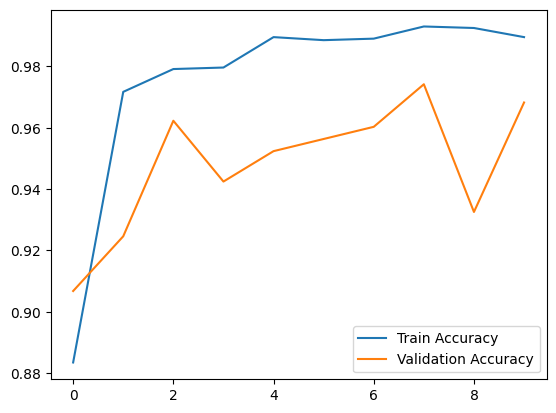

Model training complete and saved as 'mobilenetv2_rps_20250221-141827_acc0.97.h5' with test accuracy: 0.97


In [3]:
# Data Augmentation and Preprocessing
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

# Load Training and Validation Data
img_size = (160, 160)
batch_size = 32

train_generator = datagen.flow_from_directory(
    dataset_path,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'
)

val_generator = datagen.flow_from_directory(
    dataset_path,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation'
)

# Load MobileNetV2 as Feature Extractor
base_model = MobileNetV2(input_shape=(160, 160, 3), include_top=False, weights='imagenet')
base_model.trainable = False  # Freeze base model

# Custom Classifier
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(3, activation='softmax')  # 3 classes: rock, paper, scissors
])

# Compile the Model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train the Model
epochs = 10
history = model.fit(train_generator, validation_data=val_generator, epochs=epochs)

# Evaluate Model
test_loss, test_acc = model.evaluate(val_generator)

# Generate timestamp
timestamp = datetime.datetime.now().strftime("%Y%m%d-%H%M%S")

# Save the trained model with test accuracy and timestamp
model_filename = f"mobilenetv2_rps_{timestamp}_acc{test_acc:.2f}.h5"
model.save(model_filename)

# Plot Training History
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.show()

print(f"Model training complete and saved as '{model_filename}' with test accuracy: {test_acc:.2f}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
[[2.4788037e-06 9.9999750e-01 1.3686472e-08]]


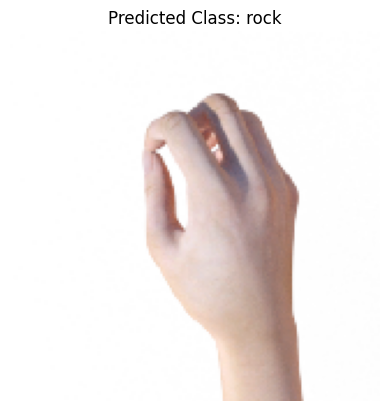

In [8]:
# prompt: Include a picture of the predicting image as well

import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.preprocessing import image

# Assuming 'model' is your trained model and 'val_generator' is your validation data generator
# ... (your existing code) ...

# Function to predict and display image
def predict_and_display_image(img_path):
    img = image.load_img(img_path, target_size=(160, 160))
    x = image.img_to_array(img)
    x = np.expand_dims(x, axis=0)
    x = x / 255.0  # Rescale

    images = np.vstack([x])
    classes = model.predict(images, batch_size=10)
    print(classes)

    predicted_class_index = np.argmax(classes)
    class_labels = list(val_generator.class_indices.keys()) # Get class labels from generator
    predicted_class = class_labels[predicted_class_index]

    plt.imshow(img)
    plt.title(f"Predicted Class: {predicted_class}")
    plt.axis('off')
    plt.show()


# Example usage (replace with the actual path to your image)
image_path = '/content/datasets/rps_extracted/rps/rock/rock01-041.png' # Example image path from dataset
predict_and_display_image(image_path)
